<a href="https://colab.research.google.com/github/SrilathaWeb/Data-Science-Cohort-20/blob/main/Project-6/Images_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 6: Image Classification with Deep Learning



This project introduces us to deep learning. The deep learning process is a huge leap forward in data science and the field is less than 15 years old. The processing is significantly different from our previous projects so you will basically be provided a walkthrough document delineating the steps - much like Project 1. Deep learning is fascinating and I just want you to go through the process so you can appreciate its power.



The data collection portion of deep learning projects is a rather complex task. In other words, there is no CSV file that we can load to serve as our training data. Constructing a training data set is a rather large undertaking. We have imported all the training images (took hours) and I will show you how you can load the training data through the "pickle" process.



There are three files in this data set:
- [the feature set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle ), i.e. images of dogs and cats ( mostly )
- [the target set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle ), i.e. the label (0/1) that something is a dog or cat ( mostly )
- [a test image]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg )





This project will classify new, unseen images of cats and dogs. This was one of the first big success stories of deep learning and we will go through the process of building a learning algorithm that will do this task. Distinguishing a picture of a cat from a picture of a dog is easy for humans to do, but had been notoriously difficult to get a computer learning to perform well on the task. Deep learning solved that.


The same data sets as above, but you can copy the links by viewing the markdown directly to bypass Google Colab's annoying "You are leaving Colab" link.




https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg


In [1]:
import pandas as pd


In [2]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [3]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

In [4]:
image_array.shape

(24946, 100, 100, 1)

In [5]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [6]:
target = pd.read_pickle( target_url )
type(target)


list

In [7]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Input


In [8]:
!wget https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle
!wget https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle
!wget https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg

--2026-06-05 20:06:13--  https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle
Resolving ddc-datascience.s3.amazonaws.com (ddc-datascience.s3.amazonaws.com)... 16.15.0.182, 52.219.220.209, 16.15.0.245, ...
Connecting to ddc-datascience.s3.amazonaws.com (ddc-datascience.s3.amazonaws.com)|16.15.0.182|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 249460166 (238M) [binary/octet-stream]
Saving to: ‘X.pickle’

X.pickle            100%[===================>] 237.90M  96.5MB/s    in 2.5s    

2026-06-05 20:06:16 (96.5 MB/s) - ‘X.pickle’ saved [249460166/249460166]

--2026-06-05 20:06:16--  https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle
Resolving ddc-datascience.s3.amazonaws.com (ddc-datascience.s3.amazonaws.com)... 16.15.0.198, 52.219.220.41, 52.219.194.49, ...
Connecting to ddc-datascience.s3.amazonaws.com (ddc-datascience.s3.amazonaws.com)|16.15.0.198|:443... connected.
HTTP request sent, awaiting respons

In [9]:
with open("X.pickle", "rb") as file:
    X = pickle.load(file)

with open("y.pickle", "rb") as file:
    y = pickle.load(file)

In [10]:
print("X shape:", X.shape)
#print("Y shape:", y.shape)
print("y length:", len(y))
print("First label:", y[0])

X shape: (24946, 100, 100, 1)
y length: 24946
First label: 0


In [11]:
y = np.array(y)

In [12]:
X = X / 255.0

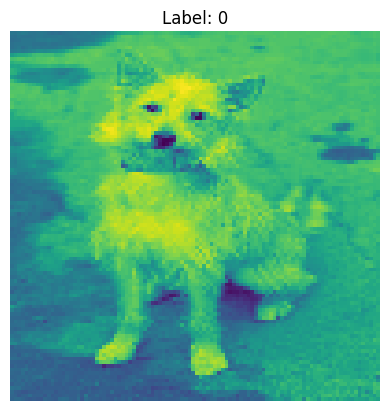

In [13]:
plt.imshow(X[0])
plt.title(f"Label: {y[0]}")
plt.axis("off")
plt.show()

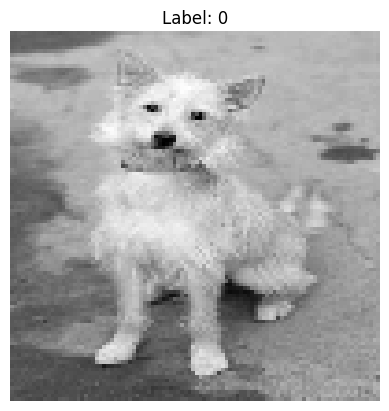

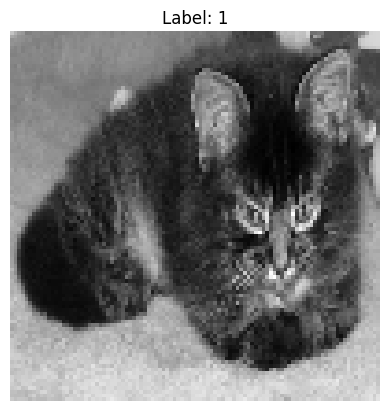

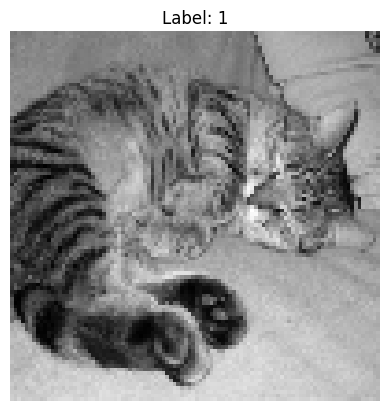

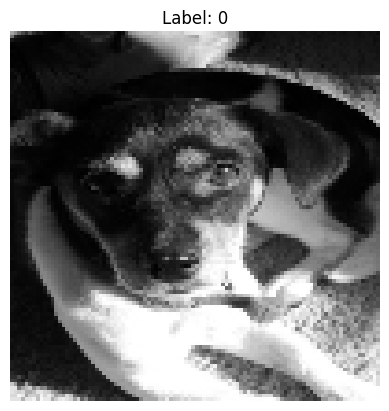

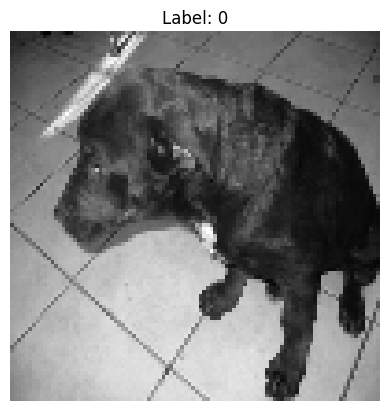

In [14]:
for i in range(5):
    plt.imshow(X[i].reshape(100, 100), cmap="gray")
    plt.title(f"Label: {y[i]}")
    plt.axis("off")
    plt.show()

In [15]:
model = Sequential()

model.add(Input(shape=X.shape[1:]))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(1, activation="sigmoid"))

model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(),
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,166,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,204,481 (8.41 MB)

 Trainable params: 2,204,481 (8.41 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(),
    metrics=["accuracy"]
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,166,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,204,481 (8.41 MB)

 Trainable params: 2,204,481 (8.41 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X,
    y,
    batch_size=32,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.6460 - loss: 0.6219 - val_accuracy: 0.7092 - val_loss: 0.5565
Epoch 2/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7508 - loss: 0.5141 - val_accuracy: 0.7353 - val_loss: 0.5441
Epoch 3/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7867 - loss: 0.4544 - val_accuracy: 0.7705 - val_loss: 0.4750
Epoch 4/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8249 - loss: 0.3945 - val_accuracy: 0.7910 - val_loss: 0.4648
Epoch 5/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8482 - loss: 0.3454 - val_accuracy: 0.7868 - val_loss: 0.4802
Epoch 6/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8728 - loss: 0.2957 - val_accuracy: 0.7786 - val_loss: 0.5173
Epoch 7/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8893 - loss: 0.2571 - val_accuracy: 0.7860 - val_loss: 0.5355
Epoch 8/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9103 - loss: 0.2114 - val_ac

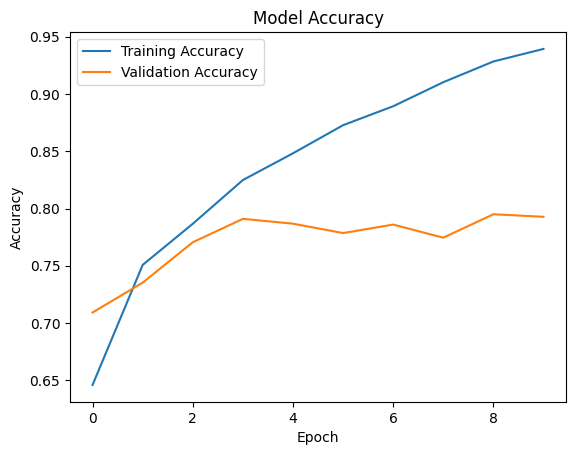

In [19]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()

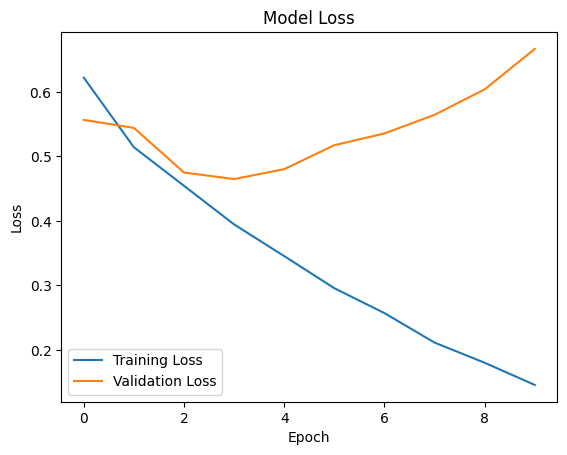

In [20]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()
plt.show()

In [21]:
# from tensorflow.keras.callbacks import EarlyStopping

# early_stop = EarlyStopping(
#     monitor="val_loss",
#     patience=2,
#     restore_best_weights=True
# )

# history = model.fit(
#     X,
#     y,
#     batch_size=32,
#     epochs=10,
#     validation_split=0.2,
#     callbacks=[early_stop]
# )

In [22]:
# plt.plot(history.history["accuracy"], label="Training Accuracy")
# plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.title("Model Accuracy")
# plt.legend()
# # plt.show()

In [23]:
# plt.plot(history.history["loss"], label="Training Loss")
# plt.plot(history.history["val_loss"], label="Validation Loss")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Model Loss")
# plt.legend()
# plt.show()

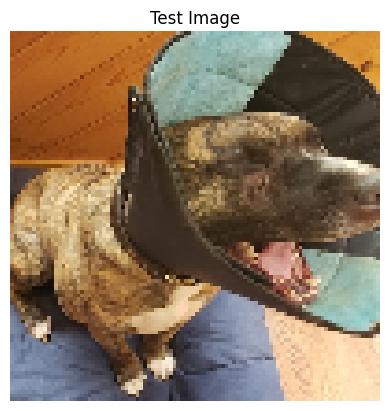

In [34]:
IMG_SIZE = X.shape[1]

test_img = cv2.imread("dog.jpg")
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_img = cv2.resize(test_img, (IMG_SIZE, IMG_SIZE))

plt.imshow(test_img)
plt.title("Test Image")
plt.axis("off")
plt.show()

In [35]:
test_img_normalized = test_img / 255.0
test_img_reshaped = np.array(test_img_normalized).reshape(-1, IMG_SIZE, IMG_SIZE, 1)

In [36]:
prediction = model.predict(test_img_reshaped)

print("Prediction value:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Prediction value: 0.0039801467


In [37]:
if prediction[0][0] >= 0.5:
    print("The model predicts: Cat")
else:
    print("The model predicts: Dog")

The model predicts: Dog


In [33]:
print("Final training accuracy:", history.history["accuracy"][-1])
print("Final validation accuracy:", history.history["val_accuracy"][-1])

Final training accuracy: 0.9393665790557861
Final validation accuracy: 0.7927855849266052


In [44]:
from skimage import io
from skimage.transform import resize
import matplotlib.pyplot as plt

def predictor(url):
    pic = io.imread(url, as_gray=True)
    pic = resize(pic, (100, 100))
    pic = pic.astype("float32")
    plt.imshow(pic)

    pic = pic[None, :, :, None]
    prediction = model.predict(pic)
    return prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


array([[1.]], dtype=float32)

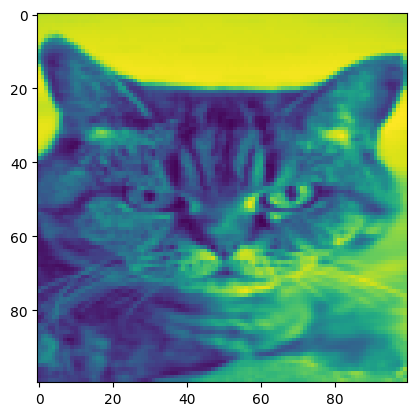

In [45]:
predictor("https://plus.unsplash.com/premium_photo-1667030474693-6d0632f97029?fm=jpg&q=60&w=3000&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MXx8Y2F0fGVufDB8fDB8fHww")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


array([[1.0068505e-05]], dtype=float32)

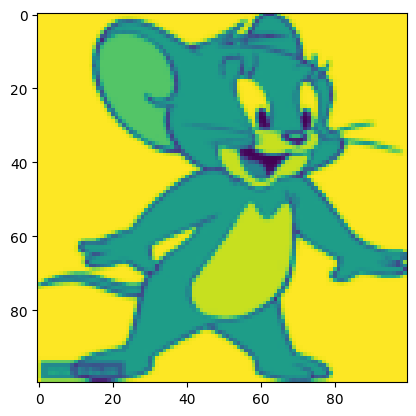

In [46]:
predictor("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRiM5_WLCtfYU_JbwpYRZiTYSeDXhWvwFlKRzpXmKIFiA&s=10")